# 05 — Feature Engineering

This notebook creates the model-ready feature matrix. We define the prediction target (volatility spikes), engineer lagged and rolling features from price and NLP data, and split into train/test sets using a time-series approach (no future leakage).


---
## Setup & Load Updated Dataset


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


BASE_DIR = Path().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_PROCESSED = BASE_DIR / "data" / "processed"

df = pd.read_csv(DATA_PROCESSED / "master_dataset.csv", parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
print(f"\nColumns ({len(df.columns)}):")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")


Shape: (4770, 18)
Date range: 2003-01-02 00:00:00 → 2021-12-30 00:00:00

Columns (18):
  Date: datetime64[ns]
  oil_close: float64
  oil_high: float64
  oil_low: float64
  oil_open: float64
  oil_volume: int64
  gold_close: float64
  gold_high: float64
  gold_low: float64
  gold_open: float64
  gold_volume: int64
  headline_count: float64
  combined_headlines: object
  keyword_risk_ratio: float64
  finbert_mean_neg: float64
  finbert_max_neg: float64
  finbert_high_fear_count: float64
  hybrid_risk_score: float64


---
## Define Target Variable — Volatility Spikes

We predict whether tomorrow will have an **abnormally large price move** (absolute return above the 90th percentile). This is a binary classification: 1 = volatility spike, 0 = normal day.

We compute separate targets for Oil and Gold.


Oil spike threshold (90th pctl):  0.0372 (3.72% daily move)
Gold spike threshold (90th pctl): 0.0177 (1.77% daily move)

Oil spike tomorrow:  477 spikes / 4770 days (10.0%)
Gold spike tomorrow: 477 spikes / 4770 days (10.0%)


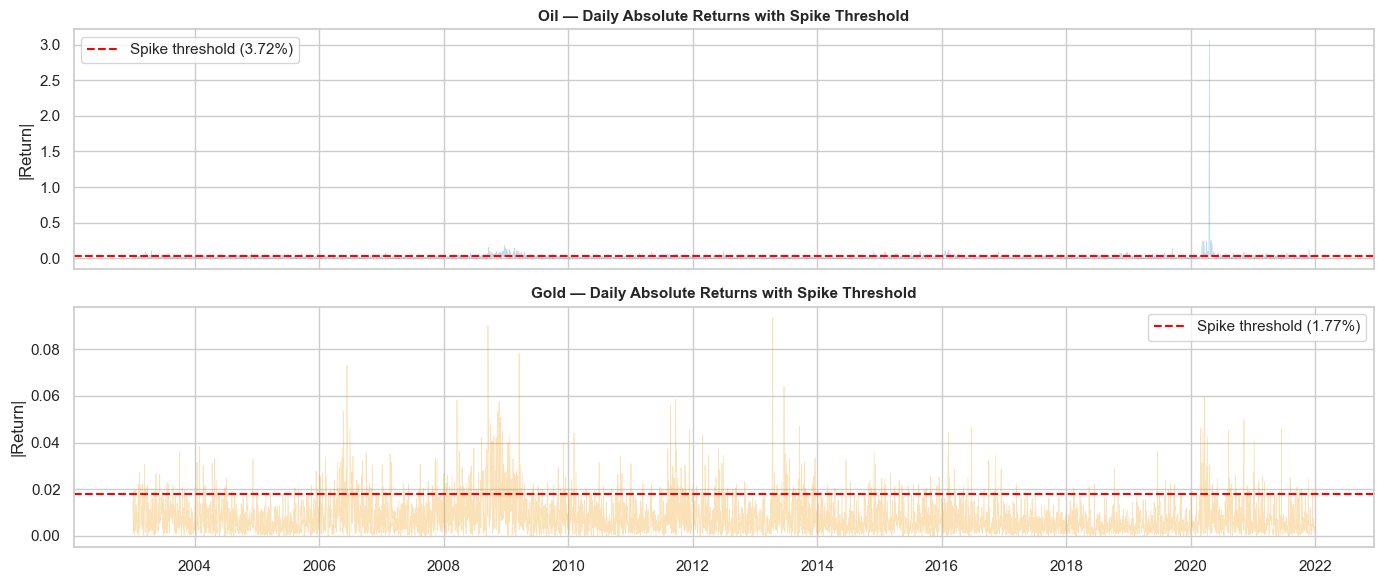

In [2]:

df['oil_return'] = df['oil_close'].pct_change()
df['gold_return'] = df['gold_close'].pct_change()
df['oil_abs_return'] = df['oil_return'].abs()
df['gold_abs_return'] = df['gold_return'].abs()

oil_threshold = df['oil_abs_return'].quantile(0.90)
gold_threshold = df['gold_abs_return'].quantile(0.90)

print(f"Oil spike threshold (90th pctl):  {oil_threshold:.4f} ({oil_threshold:.2%} daily move)")
print(f"Gold spike threshold (90th pctl): {gold_threshold:.4f} ({gold_threshold:.2%} daily move)")

df['oil_spike_tomorrow'] = (df['oil_abs_return'].shift(-1) > oil_threshold).astype(int)
df['gold_spike_tomorrow'] = (df['gold_abs_return'].shift(-1) > gold_threshold).astype(int)

print(f"\nOil spike tomorrow:  {df['oil_spike_tomorrow'].sum()} spikes / {df['oil_spike_tomorrow'].count()} days ({df['oil_spike_tomorrow'].mean():.1%})")
print(f"Gold spike tomorrow: {df['gold_spike_tomorrow'].sum()} spikes / {df['gold_spike_tomorrow'].count()} days ({df['gold_spike_tomorrow'].mean():.1%})")


fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

spike_days_oil = df[df['oil_spike_tomorrow'] == 1]
axes[0].plot(df['Date'], df['oil_abs_return'], color='#2E86C1', alpha=0.3, linewidth=0.5)
axes[0].axhline(y=oil_threshold, color='red', linestyle='--', label=f'Spike threshold ({oil_threshold:.2%})')
axes[0].set_ylabel('|Return|')
axes[0].set_title('Oil — Daily Absolute Returns with Spike Threshold', fontsize=11, fontweight='bold')
axes[0].legend()

spike_days_gold = df[df['gold_spike_tomorrow'] == 1]
axes[1].plot(df['Date'], df['gold_abs_return'], color='#F39C12', alpha=0.3, linewidth=0.5)
axes[1].axhline(y=gold_threshold, color='red', linestyle='--', label=f'Spike threshold ({gold_threshold:.2%})')
axes[1].set_ylabel('|Return|')
axes[1].set_title('Gold — Daily Absolute Returns with Spike Threshold', fontsize=11, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## Lag Features — Giving the Model Memory
Lagged values of risk scores and returns allow the model to detect patterns like "risk has been rising for 3 consecutive days" — a much stronger signal than any single day's value.


In [3]:
# NLP risk scores: lag 1-5 days
for lag in range(1, 6):
    df[f'hybrid_risk_lag{lag}'] = df['hybrid_risk_score'].shift(lag)
    df[f'keyword_risk_lag{lag}'] = df['keyword_risk_ratio'].shift(lag)
    df[f'finbert_neg_lag{lag}'] = df['finbert_mean_neg'].shift(lag)

# Absolute returns: lag 1-3 days (volatility clustering)
for lag in range(1, 4):
    df[f'oil_abs_return_lag{lag}'] = df['oil_abs_return'].shift(lag)
    df[f'gold_abs_return_lag{lag}'] = df['gold_abs_return'].shift(lag)

# Volume change: lag 1 day
df['oil_volume_lag1'] = df['oil_volume'].shift(1)
df['gold_volume_lag1'] = df['gold_volume'].shift(1)

lag_cols = [c for c in df.columns if 'lag' in c]
print(f"Lag features created: {len(lag_cols)}")
for col in lag_cols:
    print(f"  {col}")


print(f"\n=== Example: How lags look for one date ===")
sample_idx = 100
sample_date = df.loc[sample_idx, 'Date']
print(f"Date: {sample_date.strftime('%Y-%m-%d')}")
print(f"  hybrid_risk_score (today):  {df.loc[sample_idx, 'hybrid_risk_score']:.4f}")
for lag in range(1, 4):
    print(f"  hybrid_risk_lag{lag} ({lag}d ago):    {df.loc[sample_idx, f'hybrid_risk_lag{lag}']:.4f}")


Lag features created: 23
  hybrid_risk_lag1
  keyword_risk_lag1
  finbert_neg_lag1
  hybrid_risk_lag2
  keyword_risk_lag2
  finbert_neg_lag2
  hybrid_risk_lag3
  keyword_risk_lag3
  finbert_neg_lag3
  hybrid_risk_lag4
  keyword_risk_lag4
  finbert_neg_lag4
  hybrid_risk_lag5
  keyword_risk_lag5
  finbert_neg_lag5
  oil_abs_return_lag1
  gold_abs_return_lag1
  oil_abs_return_lag2
  gold_abs_return_lag2
  oil_abs_return_lag3
  gold_abs_return_lag3
  oil_volume_lag1
  gold_volume_lag1

=== Example: How lags look for one date ===
Date: 2003-05-28
  hybrid_risk_score (today):  0.3630
  hybrid_risk_lag1 (1d ago):    0.3866
  hybrid_risk_lag2 (2d ago):    0.3892
  hybrid_risk_lag3 (3d ago):    0.3409


---
## Rolling Features — Capturing Trends
Rolling averages smooth out day-to-day noise and reveal whether risk is building over time. A 5-day rising trend is a much stronger warning signal than a single high-risk day.


In [4]:

# 5-day rolling (one trading week)
df['hybrid_risk_roll5'] = df['hybrid_risk_score'].rolling(5).mean()
df['keyword_risk_roll5'] = df['keyword_risk_ratio'].rolling(5).mean()
df['finbert_neg_roll5'] = df['finbert_mean_neg'].rolling(5).mean()
df['oil_abs_return_roll5'] = df['oil_abs_return'].rolling(5).mean()
df['gold_abs_return_roll5'] = df['gold_abs_return'].rolling(5).mean()

# 20-day rolling (one trading month)
df['hybrid_risk_roll20'] = df['hybrid_risk_score'].rolling(20).mean()
df['oil_volatility_20d'] = df['oil_return'].rolling(20).std()
df['gold_volatility_20d'] = df['gold_return'].rolling(20).std()

# Risk CHANGE features: is risk rising or falling?
df['hybrid_risk_change'] = df['hybrid_risk_score'] - df['hybrid_risk_score'].shift(1)
df['hybrid_risk_change_5d'] = df['hybrid_risk_roll5'] - df['hybrid_risk_roll5'].shift(5)

# Day of week (some days are more volatile — e.g., Mondays after weekend news accumulation)
df['day_of_week'] = df['Date'].dt.dayofweek  # 0=Monday, 4=Friday


roll_cols = [c for c in df.columns if 'roll' in c or 'volatility_20d' in c or 'change' in c or c == 'day_of_week']
print(f"Rolling + other features created: {len(roll_cols)}")
for col in roll_cols:
    print(f"  {col}")

all_feature_cols = [c for c in df.columns if c not in ['Date', 'combined_headlines', 
                    'oil_spike_tomorrow', 'gold_spike_tomorrow']]
print(f"\nTotal features available: {len(all_feature_cols)}")


Rolling + other features created: 11
  hybrid_risk_roll5
  keyword_risk_roll5
  finbert_neg_roll5
  oil_abs_return_roll5
  gold_abs_return_roll5
  hybrid_risk_roll20
  oil_volatility_20d
  gold_volatility_20d
  hybrid_risk_change
  hybrid_risk_change_5d
  day_of_week

Total features available: 54


---
## Assemble Feature Matrix
Selecting model-ready features, handling NaN values from lag/rolling operations, and verifying data quality before train/test split.


In [5]:

EXCLUDE_COLS = [
    'Date', 'combined_headlines',
    'oil_spike_tomorrow', 'gold_spike_tomorrow',  # targets
    'oil_close', 'oil_high', 'oil_low', 'oil_open',  # raw prices (use returns instead)
    'gold_close', 'gold_high', 'gold_low', 'gold_open',  # raw prices
    'oil_return', 'gold_return',  # signed returns (we use abs_return)
]

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f"Features selected: {len(FEATURE_COLS)}")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col}")

# Drop rows with NaN (from lag/rolling operations)
print(f"\nRows before NaN drop: {len(df)}")
df_clean = df.dropna(subset=FEATURE_COLS + ['oil_spike_tomorrow', 'gold_spike_tomorrow'])
print(f"Rows after NaN drop:  {len(df_clean)}")
print(f"Rows lost: {len(df) - len(df_clean)} (from lag/rolling window warmup)")

X = df_clean[FEATURE_COLS]
print(f"\nRemaining NaN values: {X.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(X.select_dtypes(include=[np.number])).sum().sum()}")
print(f"\nFinal feature matrix shape: {X.shape}")


Features selected: 44
   1. oil_volume
   2. gold_volume
   3. headline_count
   4. keyword_risk_ratio
   5. finbert_mean_neg
   6. finbert_max_neg
   7. finbert_high_fear_count
   8. hybrid_risk_score
   9. oil_abs_return
  10. gold_abs_return
  11. hybrid_risk_lag1
  12. keyword_risk_lag1
  13. finbert_neg_lag1
  14. hybrid_risk_lag2
  15. keyword_risk_lag2
  16. finbert_neg_lag2
  17. hybrid_risk_lag3
  18. keyword_risk_lag3
  19. finbert_neg_lag3
  20. hybrid_risk_lag4
  21. keyword_risk_lag4
  22. finbert_neg_lag4
  23. hybrid_risk_lag5
  24. keyword_risk_lag5
  25. finbert_neg_lag5
  26. oil_abs_return_lag1
  27. gold_abs_return_lag1
  28. oil_abs_return_lag2
  29. gold_abs_return_lag2
  30. oil_abs_return_lag3
  31. gold_abs_return_lag3
  32. oil_volume_lag1
  33. gold_volume_lag1
  34. hybrid_risk_roll5
  35. keyword_risk_roll5
  36. finbert_neg_roll5
  37. oil_abs_return_roll5
  38. gold_abs_return_roll5
  39. hybrid_risk_roll20
  40. oil_volatility_20d
  41. gold_volatility_2

---
## Train/Test Split — Time-Series (No Future Leakage)

Critical: we split chronologically, not randomly. The model trains on 2003–2018 and is tested on 2019–2021 — data it has never seen. This simulates real-world deployment where you only have past data available.


Split date: 2018-03-23

=== Split Summary ===
Training: 3,800 days (2003-01-31 → 2018-03-23)
Testing:  950 days (2018-03-26 → 2021-12-30)

Oil spike ratio:
  Train: 9.7%  (367 spikes)
  Test:  11.3%  (107 spikes)

Gold spike ratio:
  Train: 10.9%  (414 spikes)
  Test:  6.4%  (61 spikes)


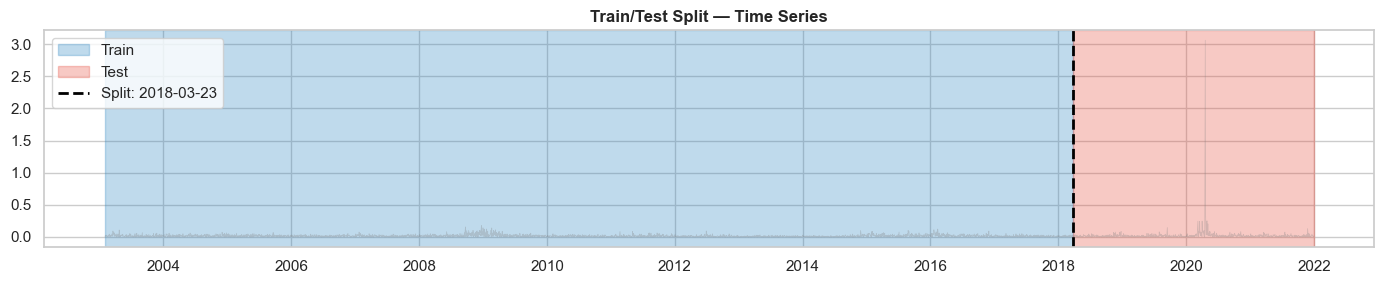

In [6]:
# Time-series split: 80% train, 20% test
split_date = df_clean['Date'].quantile(0.8)
print(f"Split date: {split_date.strftime('%Y-%m-%d')}")

train_mask = df_clean['Date'] < split_date
test_mask = df_clean['Date'] >= split_date

X_train = df_clean.loc[train_mask, FEATURE_COLS]
X_test = df_clean.loc[test_mask, FEATURE_COLS]

y_train_oil = df_clean.loc[train_mask, 'oil_spike_tomorrow']
y_test_oil = df_clean.loc[test_mask, 'oil_spike_tomorrow']

y_train_gold = df_clean.loc[train_mask, 'gold_spike_tomorrow']
y_test_gold = df_clean.loc[test_mask, 'gold_spike_tomorrow']

print(f"\n=== Split Summary ===")
print(f"Training: {len(X_train):,} days ({df_clean.loc[train_mask, 'Date'].min().strftime('%Y-%m-%d')} → {df_clean.loc[train_mask, 'Date'].max().strftime('%Y-%m-%d')})")
print(f"Testing:  {len(X_test):,} days ({df_clean.loc[test_mask, 'Date'].min().strftime('%Y-%m-%d')} → {df_clean.loc[test_mask, 'Date'].max().strftime('%Y-%m-%d')})")

print(f"\nOil spike ratio:")
print(f"  Train: {y_train_oil.mean():.1%}  ({int(y_train_oil.sum())} spikes)")
print(f"  Test:  {y_test_oil.mean():.1%}  ({int(y_test_oil.sum())} spikes)")

print(f"\nGold spike ratio:")
print(f"  Train: {y_train_gold.mean():.1%}  ({int(y_train_gold.sum())} spikes)")
print(f"  Test:  {y_test_gold.mean():.1%}  ({int(y_test_gold.sum())} spikes)")

fig, ax = plt.subplots(figsize=(14, 3))
ax.axvspan(df_clean.loc[train_mask, 'Date'].min(), split_date, alpha=0.3, color='#2E86C1', label='Train')
ax.axvspan(split_date, df_clean.loc[test_mask, 'Date'].max(), alpha=0.3, color='#E74C3C', label='Test')
ax.axvline(x=split_date, color='black', linewidth=2, linestyle='--', label=f'Split: {split_date.strftime("%Y-%m-%d")}')
ax.plot(df_clean['Date'], df_clean['oil_abs_return'], color='gray', alpha=0.3, linewidth=0.5)
ax.set_title('Train/Test Split — Time Series', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## Save Feature Matrix
Saving train/test splits to CSV for Phase 6 (Modeling). This ensures reproducibility — the exact same split is used every time.


In [7]:
train_data = df_clean.loc[train_mask, ['Date'] + FEATURE_COLS + ['oil_spike_tomorrow', 'gold_spike_tomorrow']]
test_data = df_clean.loc[test_mask, ['Date'] + FEATURE_COLS + ['oil_spike_tomorrow', 'gold_spike_tomorrow']]

train_data.to_csv(DATA_PROCESSED / "train_features.csv", index=False)
test_data.to_csv(DATA_PROCESSED / "test_features.csv", index=False)


df_clean.to_csv(DATA_PROCESSED / "master_engineered.csv", index=False)

print(f"Saved:")
print(f"  train_features.csv: {train_data.shape} ({train_data.shape[0]} rows × {train_data.shape[1]} cols)")
print(f"  test_features.csv:  {test_data.shape} ({test_data.shape[0]} rows × {test_data.shape[1]} cols)")
print(f"  master_engineered.csv: {df_clean.shape}")


print(f"\n=== Top 10 Features Correlated with Oil Spikes ===")
oil_corr = X_train.corrwith(y_train_oil).abs().sort_values(ascending=False)
for feat, corr in oil_corr.head(10).items():
    print(f"  {feat:30s}  r = {corr:.4f}")

print(f"\n=== Top 10 Features Correlated with Gold Spikes ===")
gold_corr = X_train.corrwith(y_train_gold).abs().sort_values(ascending=False)
for feat, corr in gold_corr.head(10).items():
    print(f"  {feat:30s}  r = {corr:.4f}")


Saved:
  train_features.csv: (3800, 47) (3800 rows × 47 cols)
  test_features.csv:  (950, 47) (950 rows × 47 cols)
  master_engineered.csv: (4750, 58)

=== Top 10 Features Correlated with Oil Spikes ===
  oil_volatility_20d              r = 0.3371
  oil_abs_return_roll5            r = 0.3002
  oil_abs_return                  r = 0.1989
  oil_abs_return_lag2             r = 0.1937
  oil_abs_return_lag1             r = 0.1832
  gold_volatility_20d             r = 0.1817
  oil_abs_return_lag3             r = 0.1701
  gold_abs_return_roll5           r = 0.1531
  finbert_neg_roll5               r = 0.1142
  hybrid_risk_roll20              r = 0.1083

=== Top 10 Features Correlated with Gold Spikes ===
  gold_volatility_20d             r = 0.2437
  gold_abs_return_roll5           r = 0.1856
  oil_volatility_20d              r = 0.1323
  gold_abs_return_lag2            r = 0.1119
  oil_abs_return_roll5            r = 0.1098
  gold_abs_return_lag1            r = 0.1051
  gold_abs_return_lag3  

---
## Phase 5 Summary

### What We Built
- **Target variable:** Binary volatility spike prediction (90th percentile absolute return, one day ahead)
  - Oil threshold: 3.72% daily move
  - Gold threshold: 1.77% daily move
  - ~10% positive rate (intentionally imbalanced)

- **44 features engineered:**
  - Raw signals: NLP risk scores, returns, volumes, headline count
  - 23 lag features (1-5 day memory for NLP, 1-3 day for returns/volumes)
  - 11 rolling/trend features (5-day and 20-day windows, change indicators)
  - Day of week (Monday effect)

- **Time-series train/test split:**
  - Train: 3,800 days (Jan 2003 – Mar 2018)
  - Test: 950 days (Mar 2018 – Dec 2021)
  - No future leakage — model only sees past data

### Key Design Decisions
1. Predict volatility spikes, not price direction (more actionable, statistically stronger)
2. Use absolute returns, not signed returns (direction-agnostic)
3. Exclude raw price levels (non-stationary, would cause overfitting)
4. Time-series split, not random (simulates real-world deployment)

### Files Created
- `train_features.csv` — Training data (3,800 × 47)
- `test_features.csv` — Test data (950 × 47)
- `master_engineered.csv` — Full dataset with all features

### Next Step
Phase 6 — Modeling: Train XGBoost and logistic regression to predict volatility spikes using these features.
